# Multi-Asset Portfolio Construction (Yahoo Finance ETF Version)

Flusso:
1. imposti i parametri,
2. **premi la cella di download**,
3. lavori direttamente sui prezzi ETF scaricati da Yahoo Finance.

Universo ETF mutuamente esclusivo per sleeve:
- Cash / T-Bills: `BIL`
- Intermediate Treasuries: `IEF`
- TIPS: `TIP`
- Investment Grade Credit: `LQD`
- High Yield Credit: `HYG`
- U.S. Equity: `VTI`
- Developed ex-U.S. Equity: `EFA`
- Emerging Markets Equity: `VWO`
- Gold: `GLD`
- Broad Commodities: `DBC`


In [1]:
# Se serve, esegui una volta questa cella
# %pip install -q yfinance pandas numpy matplotlib scipy openpyxl


In [2]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as spopt
from scipy.stats import norm

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

PERIODS_PER_YEAR = 252
START_DATE = "2007-01-01"
END_DATE = None                  # es. "2025-12-31"
REFRESH_DATA = True             # <- premi la cella download con True per riscaricare da Yahoo
AUTO_ADJUST = True
CACHE_FILENAME = "yahoo_etf_prices.csv"

ETF_UNIVERSE = {
    "Cash / T-Bills": "BIL",
    "Intermediate Treasuries": "IEF",
    "TIPS": "TIP",
    "Investment Grade Credit": "LQD",
    "High Yield Credit": "HYG",
    "U.S. Equity": "VTI",
    "Developed ex-U.S. Equity": "EFA",
    "Emerging Markets Equity": "VWO",
    "Gold": "GLD",
    "Broad Commodities": "DBC",
}

UNIVERSE_TABLE = pd.DataFrame(
    {"asset_class": list(ETF_UNIVERSE.keys()), "ticker": list(ETF_UNIVERSE.values())}
)

DATA_DIR = Path.cwd() / "data" / "raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = DATA_DIR / CACHE_FILENAME

UNIVERSE_TABLE


,asset_class,ticker
0,Cash / T-Bills,BIL
1,Intermediate Treasuries,IEF
2,TIPS,TIP
3,Investment Grade Credit,LQD
4,High Yield Credit,HYG
5,U.S. Equity,VTI
6,Developed ex-U.S. Equity,EFA
7,Emerging Markets Equity,VWO
8,Gold,GLD
9,Broad Commodities,DBC


## Download dati Yahoo Finance

In [3]:

import yfinance as yf

def _extract_close_frame(raw: pd.DataFrame) -> pd.DataFrame:
    if raw.empty:
        raise ValueError("Yahoo Finance returned an empty DataFrame.")
    if isinstance(raw.columns, pd.MultiIndex):
        for field in ["Adj Close", "Close"]:
            if field in raw.columns.get_level_values(0):
                close = raw[field].copy()
                close.columns.name = None
                return close
        raise ValueError(f"Could not locate Close/Adj Close in columns: {raw.columns}")
    return raw.copy()

def download_prices_from_yahoo(
    universe: dict[str, str],
    start: str,
    end: str | None = None,
    auto_adjust: bool = True,
    refresh: bool = True,
    cache_path: str | Path = CACHE_PATH,
) -> pd.DataFrame:
    cache_path = Path(cache_path)

    if cache_path.exists() and not refresh:
        prices = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        prices = prices.sort_index()
        print(f"Loaded cached prices from {cache_path}")
        return prices

    tickers = list(universe.values())
    raw = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=auto_adjust,
        progress=False,
        group_by="column",
        threads=True,
    )
    close = _extract_close_frame(raw)

    reverse_map = {ticker: asset for asset, ticker in universe.items()}
    close = close.rename(columns=reverse_map)
    close = close.reindex(columns=list(universe.keys()))
    close = close.sort_index().dropna(how="all").dropna(axis=0, how="any")

    if close.empty:
        raise ValueError("Downloaded prices are empty after alignment / NaN filtering.")

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    close.to_csv(cache_path)
    print(f"Downloaded prices from Yahoo and saved cache to {cache_path}")
    return close

prices = download_prices_from_yahoo(
    universe=ETF_UNIVERSE,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=AUTO_ADJUST,
    refresh=REFRESH_DATA,
    cache_path=CACHE_PATH,
)

prices.tail()


Downloaded prices from Yahoo and saved cache to /content/data/raw/yahoo_etf_prices.csv


,Cash / T-Bills,Intermediate Treasuries,TIPS,Investment Grade Credit,High Yield Credit,U.S. Equity,Developed ex-U.S. Equity,Emerging Markets Equity,Gold,Broad Commodities
Date,,,,,,,,,,
2026-04-24,91.610001,95.559998,111.800003,109.599998,80.480003,352.049988,101.769997,59.020000,433.250000,29.860001
2026-04-27,91.620003,95.339996,111.769997,109.290001,80.510002,352.529999,101.379997,58.730000,429.890015,30.090000
2026-04-28,91.629997,95.250000,111.730003,109.339996,80.400002,350.630005,100.959999,58.320000,421.910004,30.340000
2026-04-29,91.629997,94.800003,111.389999,108.730003,80.129997,350.209991,99.930000,58.080002,417.410004,31.080000
2026-04-30,91.642601,95.035004,111.459999,108.855003,80.190002,351.330109,101.305000,58.375000,425.219910,30.840000


## Returns e diagnostica di base

In [4]:

def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return np.log(prices).diff().dropna(how="all")

returns = compute_log_returns(prices)
rf_annual = returns["Cash / T-Bills"].mean() * PERIODS_PER_YEAR

display(returns.tail())
print("Sample start:", returns.index.min().date())
print("Sample end:  ", returns.index.max().date())
print("Risk-free proxy (annualized):", round(float(rf_annual), 4))


,Cash / T-Bills,Intermediate Treasuries,TIPS,Investment Grade Credit,High Yield Credit,U.S. Equity,Developed ex-U.S. Equity,Emerging Markets Equity,Gold,Broad Commodities
Date,,,,,,,,,,
2026-04-24,0.000218,0.001990,0.002059,0.000730,0.001368,0.006412,0.005221,0.018814,0.005114,-0.001004
2026-04-27,0.000109,-0.002305,-0.000268,-0.002832,0.000373,0.001363,-0.003840,-0.004926,-0.007786,0.007673
2026-04-28,0.000109,-0.000944,-0.000358,0.000457,-0.001367,-0.005404,-0.004151,-0.007006,-0.018737,0.008274
2026-04-29,0.000000,-0.004736,-0.003048,-0.005594,-0.003364,-0.001199,-0.010254,-0.004124,-0.010723,0.024098
2026-04-30,0.000138,0.002476,0.000628,0.001149,0.000749,0.003193,0.013666,0.005066,0.018538,-0.007752


Sample start: 2007-05-31
Sample end:   2026-04-30
Risk-free proxy (annualized): 0.0134


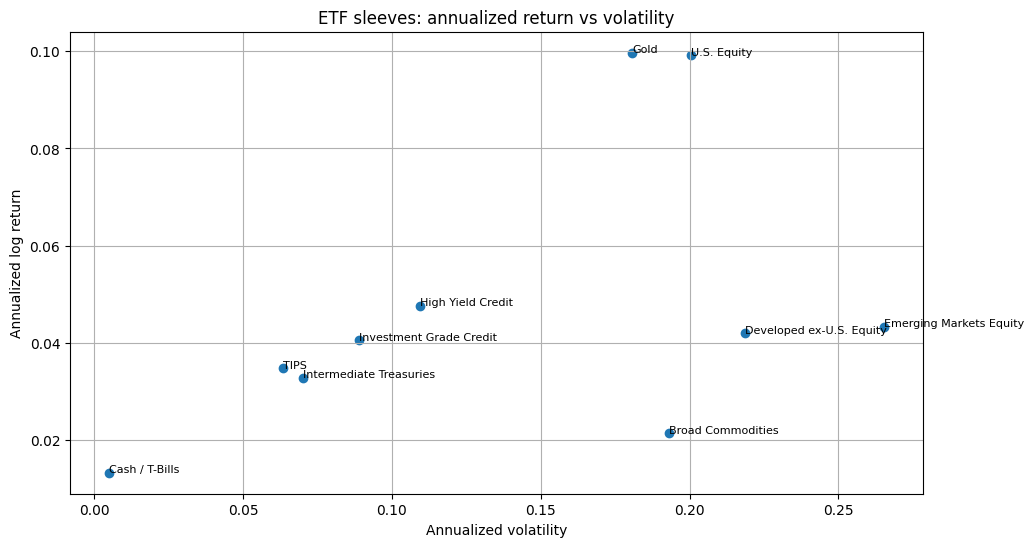

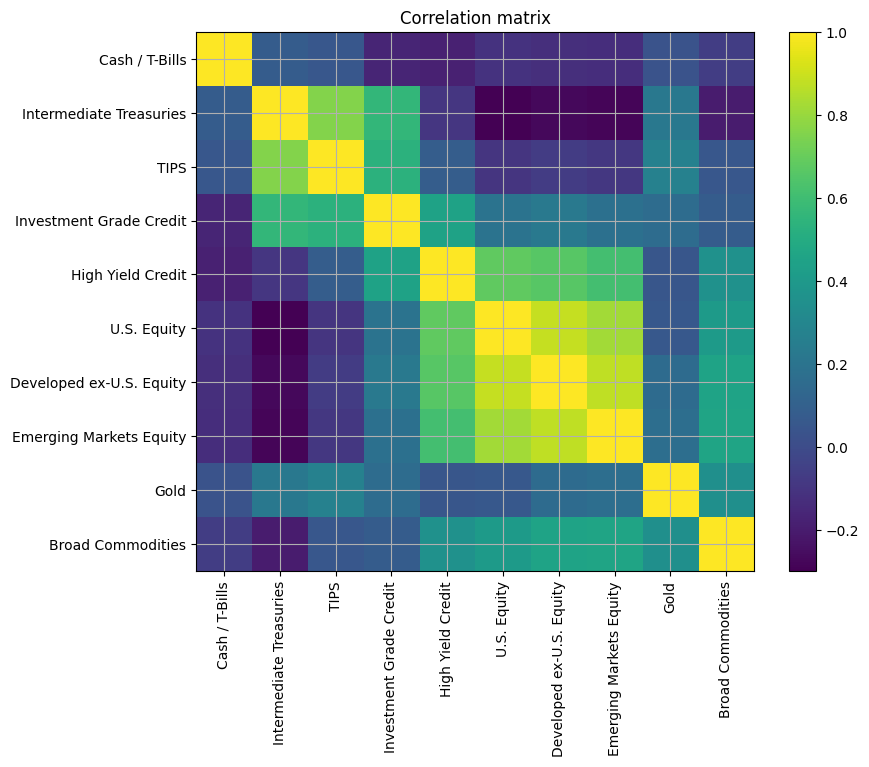

In [5]:

asset_mu = returns.mean() * PERIODS_PER_YEAR
asset_vol = returns.std() * np.sqrt(PERIODS_PER_YEAR)
corr = returns.corr()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(asset_vol, asset_mu)
for x, y, label in zip(asset_vol, asset_mu, asset_mu.index):
    ax.annotate(label, (x, y), fontsize=8)
ax.set_title("ETF sleeves: annualized return vs volatility")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized log return")
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax)
plt.show()


## Helper functions

In [6]:

EPS = 1e-12

def annualized_return(x, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: annualized_return(s, periods_per_year))
    s = x.dropna()
    if len(s) == 0:
        return np.nan
    return float(np.exp(s.sum() * periods_per_year / len(s)) - 1.0)

def annualized_volatility(x, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.std(ddof=1) * np.sqrt(periods_per_year)
    return float(x.dropna().std(ddof=1) * np.sqrt(periods_per_year))

def annualized_downside_volatility(x, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: annualized_downside_volatility(s, periods_per_year))
    s = x.dropna()
    down = s[s < 0]
    return float(down.std(ddof=1) * np.sqrt(periods_per_year)) if len(down) > 1 else 0.0

def historic_var(x, periods_per_year=252, level=0.05):
    if isinstance(x, pd.DataFrame):
        return x.quantile(level, axis=0) * np.sqrt(periods_per_year)
    return float(x.dropna().quantile(level) * np.sqrt(periods_per_year))

def parametric_var(x, periods_per_year=252, level=0.05):
    z = norm.ppf(1 - level)
    if isinstance(x, pd.DataFrame):
        return (x.mean(axis=0) - z * x.std(axis=0, ddof=1)) * np.sqrt(periods_per_year)
    s = x.dropna()
    return float((s.mean() - z * s.std(ddof=1)) * np.sqrt(periods_per_year))

def historic_es(x, periods_per_year=252, level=0.05):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: historic_es(s, periods_per_year, level))
    s = x.dropna()
    cutoff = s.quantile(level)
    return float(s[s <= cutoff].mean() * np.sqrt(periods_per_year))

def parametric_es(x, periods_per_year=252, level=0.05):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: parametric_es(s, periods_per_year, level))
    s = x.dropna()
    mu = s.mean()
    sigma = s.std(ddof=1)
    z = norm.ppf(1 - level)
    cutoff = mu - z * sigma
    return float(s[s <= cutoff].mean() * np.sqrt(periods_per_year))

def max_drawdown(x):
    if isinstance(x, pd.DataFrame):
        return x.apply(max_drawdown)
    s = x.dropna()
    wealth = np.exp(s.cumsum())
    dd = wealth / wealth.cummax() - 1.0
    return float(dd.min())

def sharpe_ratio(x, risk_free_rate, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: sharpe_ratio(s, risk_free_rate, periods_per_year))
    return (annualized_return(x, periods_per_year) - risk_free_rate) / (annualized_volatility(x, periods_per_year) + EPS)

def sortino_ratio(x, risk_free_rate, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: sortino_ratio(s, risk_free_rate, periods_per_year))
    return (annualized_return(x, periods_per_year) - risk_free_rate) / (annualized_downside_volatility(x, periods_per_year) + EPS)

def omega_ratio(x, threshold, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: omega_ratio(s, threshold, periods_per_year))
    s = x.dropna()
    threshold_period = np.log1p((1 + threshold) ** (1 / periods_per_year) - 1)
    gains = np.maximum(0.0, s - threshold_period)
    losses = np.maximum(0.0, threshold_period - s)
    return float(gains.sum() / (losses.sum() + EPS))

def calmar_ratio(x, periods_per_year=252):
    if isinstance(x, pd.DataFrame):
        return x.apply(lambda s: calmar_ratio(s, periods_per_year))
    return annualized_return(x, periods_per_year) / (abs(max_drawdown(x)) + EPS)

def portfolio_series(returns, weights):
    w = np.asarray(weights, dtype=float)
    return pd.Series(returns.values @ w, index=returns.index, name="portfolio")

def portfolio_mean_return(weights, returns, periods_per_year=252):
    return float(np.dot(np.asarray(weights), returns.mean().values) * periods_per_year)

def portfolio_variance(weights, returns, periods_per_year=252):
    sigma = returns.cov().values
    w = np.asarray(weights, dtype=float)
    return float(w @ sigma @ w * periods_per_year)

def portfolio_volatility(weights, returns, periods_per_year=252):
    return np.sqrt(portfolio_variance(weights, returns, periods_per_year))

def portfolio_downside_volatility(weights, returns, periods_per_year=252):
    rp = portfolio_series(returns, weights)
    return annualized_downside_volatility(rp, periods_per_year)

def sortino_objective(weights, returns, risk_free_rate, periods_per_year=252):
    return -((portfolio_mean_return(weights, returns, periods_per_year) - risk_free_rate) /
             (portfolio_downside_volatility(weights, returns, periods_per_year) + EPS))

def base_constraints(returns, target_return=None, periods_per_year=252):
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    if target_return is not None:
        cons.append({"type": "eq", "fun": lambda w, r=returns, t=target_return, p=periods_per_year: portfolio_mean_return(w, r, p) - t})
    return cons

def long_only_bounds(columns, max_weights=None):
    if max_weights is None:
        max_weights = [1.0] * len(columns)
    return list(zip([0.0] * len(columns), max_weights))

def flag_from_assets(columns, selected):
    f = pd.Series(0, index=columns, dtype=int)
    for s in selected:
        f.loc[s] = 1
    return f

def group_sum(weights, flag):
    x = pd.Series(weights, index=flag.index)
    return float(x.loc[flag == 1].sum())

def group_lower_bound(weights, flag, target):
    return group_sum(weights, flag) - target

def group_upper_bound(weights, flag, target):
    return target - group_sum(weights, flag)

def relative_group_lower_bound(weights, num_flag, den_flag, target):
    num = group_sum(weights, num_flag)
    den = group_sum(weights, den_flag)
    return num / (den + EPS) - target

def solve_min_vol(returns, bounds, constraints, periods_per_year=252):
    w0 = np.repeat(1 / returns.shape[1], returns.shape[1])
    return spopt.minimize(portfolio_volatility, w0, args=(returns, periods_per_year), method="SLSQP",
                          bounds=bounds, constraints=constraints,
                          options={"disp": False, "ftol": 1e-10, "maxiter": 2000})

def solve_min_downside_vol(returns, bounds, constraints, periods_per_year=252):
    w0 = np.repeat(1 / returns.shape[1], returns.shape[1])
    return spopt.minimize(portfolio_downside_volatility, w0, args=(returns, periods_per_year), method="SLSQP",
                          bounds=bounds, constraints=constraints,
                          options={"disp": False, "ftol": 1e-10, "maxiter": 2000})

def solve_sortino(returns, bounds, constraints, risk_free_rate, periods_per_year=252):
    w0 = np.repeat(1 / returns.shape[1], returns.shape[1])
    return spopt.minimize(sortino_objective, w0, args=(returns, risk_free_rate, periods_per_year), method="SLSQP",
                          bounds=bounds, constraints=constraints,
                          options={"disp": False, "ftol": 1e-10, "maxiter": 2000})

def _risk_contributions(weights, cov):
    w = np.asarray(weights, dtype=float)
    port_var = float(w @ cov @ w)
    mrc = cov @ w
    return w * mrc / (port_var + EPS)

def solve_erc(returns, bounds, constraints):
    cov = returns.cov().values
    n = returns.shape[1]
    target = np.repeat(1 / n, n)
    def obj(w):
        rc = _risk_contributions(w, cov)
        return float(np.sum((rc - target) ** 2))
    w0 = np.repeat(1 / n, n)
    return spopt.minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=constraints,
                          options={"disp": False, "ftol": 1e-12, "maxiter": 3000})

def solve_max_div(returns, bounds, constraints, periods_per_year=252):
    sigma = returns.cov().values * periods_per_year
    vols = np.sqrt(np.diag(sigma))
    def obj(w):
        w = np.asarray(w, dtype=float)
        port_vol = np.sqrt(max(float(w @ sigma @ w), EPS))
        return - float((w @ vols) / port_vol)
    w0 = np.repeat(1 / returns.shape[1], returns.shape[1])
    return spopt.minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=constraints,
                          options={"disp": False, "ftol": 1e-12, "maxiter": 3000})

def resampled_mean_variance_weights(returns, bounds, constraint_builder, periods_per_year=252, n_bootstrap=200, seed=42):
    rng = np.random.default_rng(seed)
    n = len(returns)
    weight_list = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        sample = returns.iloc[idx].reset_index(drop=True)
        cons = constraint_builder(sample)
        res = solve_min_vol(sample, bounds, cons, periods_per_year)
        if res.success and np.isfinite(res.fun):
            weight_list.append(res.x)
    if not weight_list:
        raise RuntimeError("Resampled MV failed in all bootstrap runs.")
    boot_w = pd.DataFrame(weight_list, columns=returns.columns)
    avg_w = boot_w.mean(axis=0).clip(lower=0.0)
    avg_w = avg_w / avg_w.sum()
    return avg_w, boot_w

def zscore(s):
    s = pd.Series(s, dtype=float)
    return (s - s.mean()) / (s.std(ddof=0) + EPS)

def build_endogenous_bl_views(returns, periods_per_year=252, n_views=3, momentum_window=126, drawdown_window=126, corr_window=63, view_scale=0.35):
    simple = np.exp(returns) - 1.0
    momentum = (1.0 + simple.tail(momentum_window)).prod() - 1.0
    wealth = (1.0 + simple.tail(drawdown_window)).cumprod()
    latest_drawdown = wealth.div(wealth.cummax()).iloc[-1] - 1.0
    drawdown_score = -latest_drawdown
    avg_abs_corr = simple.tail(corr_window).corr().abs().replace(1.0, np.nan).mean()
    diversification_score = -avg_abs_corr.fillna(avg_abs_corr.mean())
    vol_annual = returns.tail(momentum_window).std() * np.sqrt(periods_per_year)
    composite = 0.50 * zscore(momentum) + 0.30 * zscore(drawdown_score) + 0.20 * zscore(diversification_score)
    table = pd.DataFrame({
        "momentum_6m": momentum,
        "latest_drawdown": latest_drawdown,
        "avg_abs_corr": avg_abs_corr,
        "vol_annual": vol_annual,
        "composite_score": composite,
    }).sort_values("composite_score", ascending=False)
    table["rank"] = np.arange(1, len(table) + 1)

    n_assets = len(table)
    n_views = max(1, min(n_views, n_assets // 2))
    top_assets = table.index[:n_views]
    bottom_assets = table.index[-n_views:][::-1]
    score_range = max(float(composite.max() - composite.min()), EPS)

    P_rows, q_vals, conf_vals, names = [], [], [], []
    for i, (long_asset, short_asset) in enumerate(zip(top_assets, bottom_assets), start=1):
        spread = float(composite.loc[long_asset] - composite.loc[short_asset])
        row = pd.Series(0.0, index=returns.columns)
        row.loc[long_asset] = 1.0
        row.loc[short_asset] = -1.0
        view_vol = np.sqrt(returns[[long_asset, short_asset]].cov().values.sum() * periods_per_year / 2 + EPS)
        q = float(view_scale * (spread / score_range) * view_vol)
        conf = float(np.clip(abs(spread) / score_range, 0.35, 0.85))
        P_rows.append(row)
        q_vals.append(q)
        conf_vals.append(conf)
        names.append(f"View {i}: {long_asset} > {short_asset}")

    P = pd.DataFrame(P_rows, index=names)
    q = pd.Series(q_vals, index=names, name="q_annual")
    confidences = pd.Series(conf_vals, index=names, name="confidence")
    return table, P, q, confidences

def black_litterman_posterior_returns(cov_annual, pi, P, q, confidences, tau=1/15):
    sigma = cov_annual.values
    pi_vec = pi.values.reshape(-1, 1)
    P_mat = P.values
    q_vec = q.values.reshape(-1, 1)
    omega_diag = []
    for i, conf in enumerate(confidences.values):
        p_i = P_mat[i:i+1, :]
        omega_i = ((1.0 / conf) - 1.0) * float(p_i @ (tau * sigma) @ p_i.T)
        omega_diag.append(max(omega_i, EPS))
    Omega = np.diag(omega_diag)
    middle = np.linalg.inv(np.linalg.inv(tau * sigma) + P_mat.T @ np.linalg.inv(Omega) @ P_mat)
    posterior = middle @ (np.linalg.inv(tau * sigma) @ pi_vec + P_mat.T @ np.linalg.inv(Omega) @ q_vec)
    return pd.Series(posterior.ravel(), index=cov_annual.index, name="bl_posterior")

def implied_equilibrium_returns(cov_annual, equilibrium_weights, risk_free_rate, risk_aversion=3.0):
    return pd.Series(risk_free_rate + risk_aversion * (cov_annual.values @ equilibrium_weights.values),
                     index=cov_annual.index, name="pi")

def proxy_equilibrium_weights(prices):
    mkt = prices.div(prices.sum(axis=1), axis=0)
    w = mkt.mean(axis=0).astype(float)
    return w / w.sum()

def stationary_bootstrap_sample(returns, expected_length=20, horizon=252, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    n = len(returns)
    p = 1.0 / expected_length
    idx = []
    start = int(rng.integers(0, n))
    idx.append(start)
    while len(idx) < horizon:
        if rng.random() < p:
            nxt = int(rng.integers(0, n))
        else:
            nxt = (idx[-1] + 1) % n
        idx.append(nxt)
    return returns.iloc[idx].reset_index(drop=True)

def rolling_walk_forward(returns, weight_builders, train_window=756, rebalance_every=21, cost_bps_per_unit=10.0):
    index = returns.index
    allocators = list(weight_builders.keys())
    gross = {k: [] for k in allocators}
    net = {k: [] for k in allocators}
    weight_history = {k: [] for k in allocators}
    turnover_history = {k: [] for k in allocators}
    prev_w = {k: pd.Series(0.0, index=returns.columns) for k in allocators}

    rebalance_starts = list(range(train_window, len(returns) - 1, rebalance_every))
    for start in rebalance_starts:
        train = returns.iloc[start-train_window:start]
        end = min(start + rebalance_every, len(returns))
        test = returns.iloc[start:end]
        for name, builder in weight_builders.items():
            w = builder(train).reindex(returns.columns).astype(float)
            w = w.clip(lower=0.0)
            w = w / w.sum()
            turnover = float(np.abs(w - prev_w[name]).sum())
            daily_cost_log = np.log(max(1e-12, 1.0 - turnover * cost_bps_per_unit / 10000.0))
            rp_gross = portfolio_series(test, w)
            rp_net = rp_gross.copy()
            if len(rp_net) > 0:
                rp_net.iloc[0] += daily_cost_log
            gross[name].append(rp_gross)
            net[name].append(rp_net)
            weight_history[name].append(pd.DataFrame([w.values], index=[test.index[0]], columns=returns.columns))
            turnover_history[name].append(pd.Series(turnover, index=[test.index[0]]))
            prev_w[name] = w

    gross = pd.DataFrame({k: pd.concat(v).sort_index() for k, v in gross.items()})
    net = pd.DataFrame({k: pd.concat(v).sort_index() for k, v in net.items()})
    weights = {k: pd.concat(v).sort_index() for k, v in weight_history.items()}
    turnover = pd.DataFrame({k: pd.concat(v).sort_index() for k, v in turnover_history.items()})
    return gross, net, weights, turnover


## Portfolio constraints e Black-Litterman endogeno

In [7]:

target_return = 0.08
max_weights_map = {
    "Cash / T-Bills": 0.15,
    "Intermediate Treasuries": 0.25,
    "TIPS": 0.20,
    "Investment Grade Credit": 0.20,
    "High Yield Credit": 0.15,
    "U.S. Equity": 0.35,
    "Developed ex-U.S. Equity": 0.25,
    "Emerging Markets Equity": 0.20,
    "Gold": 0.15,
    "Broad Commodities": 0.10,
}
bounds = long_only_bounds(returns.columns, [max_weights_map[c] for c in returns.columns])

flag_defensive = flag_from_assets(returns.columns, ["Cash / T-Bills", "Intermediate Treasuries", "TIPS"])
flag_credit = flag_from_assets(returns.columns, ["Investment Grade Credit", "High Yield Credit"])
flag_equity = flag_from_assets(returns.columns, ["U.S. Equity", "Developed ex-U.S. Equity", "Emerging Markets Equity"])
flag_non_us_equity = flag_from_assets(returns.columns, ["Developed ex-U.S. Equity", "Emerging Markets Equity"])
flag_real_assets = flag_from_assets(returns.columns, ["Gold", "Broad Commodities"])
flag_hy = flag_from_assets(returns.columns, ["High Yield Credit"])

def unconstrained_builder(sample_returns):
    return base_constraints(sample_returns, target_return=target_return, periods_per_year=PERIODS_PER_YEAR)

def constrained_builder(sample_returns):
    return base_constraints(sample_returns, target_return=target_return, periods_per_year=PERIODS_PER_YEAR) + [
        {"type": "ineq", "fun": group_lower_bound, "args": (flag_defensive, 0.15)},
        {"type": "ineq", "fun": group_upper_bound, "args": (flag_defensive, 0.45)},
        {"type": "ineq", "fun": group_lower_bound, "args": (flag_credit, 0.10)},
        {"type": "ineq", "fun": group_upper_bound, "args": (flag_credit, 0.35)},
        {"type": "ineq", "fun": group_lower_bound, "args": (flag_equity, 0.35)},
        {"type": "ineq", "fun": group_upper_bound, "args": (flag_equity, 0.70)},
        {"type": "ineq", "fun": relative_group_lower_bound, "args": (flag_non_us_equity, flag_equity, 0.20)},
        {"type": "ineq", "fun": group_lower_bound, "args": (flag_real_assets, 0.05)},
        {"type": "ineq", "fun": group_upper_bound, "args": (flag_real_assets, 0.20)},
        {"type": "ineq", "fun": relative_group_lower_bound, "args": (flag_hy, flag_credit, 0.20)},
    ]

proxy_w = proxy_equilibrium_weights(prices)
pi = implied_equilibrium_returns(returns.cov() * PERIODS_PER_YEAR, proxy_w, rf_annual, risk_aversion=3.0)
signal_table, P, q, confidences = build_endogenous_bl_views(returns)
bl_mu = black_litterman_posterior_returns(returns.cov() * PERIODS_PER_YEAR, pi, P, q, confidences, tau=1/15)

display(signal_table.round(4))
display(pd.concat([q, confidences], axis=1))


,momentum_6m,latest_drawdown,avg_abs_corr,vol_annual,composite_score,rank
Gold,0.1670,-0.1425,0.2951,0.3264,1.4563,1
Broad Commodities,0.4112,-0.0077,0.3412,0.2070,1.3888,2
Cash / T-Bills,0.0183,0.0000,0.1843,0.0019,-0.0340,3
Developed ex-U.S. Equity,0.0782,-0.0412,0.5623,0.1693,-0.0759,4
Emerging Markets Equity,0.0704,-0.0136,0.5412,0.1758,-0.2792,5
U.S. Equity,0.0458,-0.0034,0.4832,0.1364,-0.3645,6
TIPS,0.0042,-0.0038,0.3983,0.0333,-0.3998,7
Intermediate Treasuries,-0.0076,-0.0241,0.4928,0.0460,-0.4454,8
Investment Grade Credit,-0.0141,-0.0183,0.5598,0.0548,-0.6202,9
High Yield Credit,0.0167,-0.0057,0.5849,0.0410,-0.6261,10


,q_annual,confidence
View 1: Gold > High Yield Credit,0.053377,0.85
View 2: Broad Commodities > Investment Grade Credit,0.052258,0.85
View 3: Cash / T-Bills > Intermediate Treasuries,0.003449,0.35


## Solve allocators

In [8]:

def solve_bl_min_vol(sample_returns, bounds, constraints, risk_free_rate):
    proxy_w = proxy_equilibrium_weights(np.exp(sample_returns.cumsum()))
    cov_annual = sample_returns.cov() * PERIODS_PER_YEAR
    pi = implied_equilibrium_returns(cov_annual, proxy_w, risk_free_rate, risk_aversion=3.0)
    _, P, q, confidences = build_endogenous_bl_views(sample_returns)
    mu_bl = black_litterman_posterior_returns(cov_annual, pi, P, q, confidences, tau=1/15)

    def mean_constraint(w, mu=mu_bl, target=target_return):
        return float(np.dot(w, mu.values) - target)

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}, {"type": "eq", "fun": mean_constraint}]
    res = solve_min_vol(sample_returns, bounds, cons, PERIODS_PER_YEAR)
    return res

allocations = {}

res = solve_min_vol(returns, bounds, unconstrained_builder(returns), PERIODS_PER_YEAR)
allocations["Mean-Variance"] = pd.Series(res.x, index=returns.columns)

res = solve_min_vol(returns, bounds, constrained_builder(returns), PERIODS_PER_YEAR)
allocations["Constrained MV"] = pd.Series(res.x, index=returns.columns)

res = solve_min_downside_vol(returns, bounds, constrained_builder(returns), PERIODS_PER_YEAR)
allocations["Downside Risk"] = pd.Series(res.x, index=returns.columns)

res = solve_sortino(returns, bounds, base_constraints(returns, target_return=None), rf_annual, PERIODS_PER_YEAR)
allocations["Sortino"] = pd.Series(res.x, index=returns.columns)

res = solve_erc(returns, bounds, base_constraints(returns, target_return=None))
allocations["ERC"] = pd.Series(res.x, index=returns.columns)

res = solve_max_div(returns, bounds, base_constraints(returns, target_return=None), PERIODS_PER_YEAR)
allocations["Maximum Diversification"] = pd.Series(res.x, index=returns.columns)

resampled_w, resampled_boot = resampled_mean_variance_weights(
    returns=returns,
    bounds=bounds,
    constraint_builder=unconstrained_builder,
    periods_per_year=PERIODS_PER_YEAR,
    n_bootstrap=200,
    seed=42,
)
allocations["Resampled MV"] = resampled_w

res = solve_bl_min_vol(returns, bounds, unconstrained_builder(returns), rf_annual)
allocations["Endogenous BL"] = pd.Series(res.x, index=returns.columns)

weights_df = pd.DataFrame(allocations).T
weights_df = weights_df.div(weights_df.sum(axis=1), axis=0)
weights_df.round(4)


,Cash / T-Bills,Intermediate Treasuries,TIPS,Investment Grade Credit,High Yield Credit,U.S. Equity,Developed ex-U.S. Equity,Emerging Markets Equity,Gold,Broad Commodities
Mean-Variance,0.0000,0.000,0.0000,0.0000,0.1500,0.3500,0.1500,0.2000,0.1500,0.0000
Constrained MV,0.0000,0.000,0.1500,0.0000,0.1500,0.3500,0.0000,0.2000,0.1500,0.0000
Downside Risk,0.0000,0.000,0.1500,0.0000,0.1500,0.3500,0.0000,0.2000,0.1500,0.0000
Sortino,0.1500,0.250,0.2000,0.0668,0.0000,0.1832,0.0000,0.0000,0.1500,0.0000
ERC,0.0584,0.250,0.1984,0.1157,0.0948,0.0556,0.0469,0.0403,0.0743,0.0656
Maximum Diversification,0.1500,0.250,0.2000,0.0452,0.0771,0.0978,0.0000,0.0192,0.0849,0.0758
Resampled MV,0.0649,0.168,0.1273,0.1052,0.0697,0.2868,0.0158,0.0147,0.1342,0.0136
Endogenous BL,0.0000,0.000,0.0000,0.0000,0.0000,0.3000,0.2500,0.2000,0.1500,0.1000


,AnnRet,AnnVol,DownVol,HistVaR5,HistES5,ParVaR5,ParES5,MaxDD,Sharpe,Sortino,Omega,Calmar
Sortino,0.0544,0.0574,0.0431,-0.0889,-0.1338,-0.0911,-0.1359,-0.1534,0.7157,0.9524,1.1096,0.3548
Resampled MV,0.0637,0.0807,0.0650,-0.1171,-0.1938,-0.1289,-0.2043,-0.2512,0.6244,0.7749,1.1033,0.2538
Maximum Diversification,0.0443,0.0535,0.0407,-0.0811,-0.1255,-0.0852,-0.1309,-0.1725,0.5782,0.7597,1.0825,0.2566
ERC,0.0441,0.0614,0.0475,-0.0906,-0.1437,-0.0982,-0.1541,-0.2039,0.5013,0.6478,1.0724,0.2164
Downside Risk,0.0732,0.1352,0.1106,-0.1941,-0.3302,-0.2180,-0.3597,-0.4214,0.4428,0.5414,1.0752,0.1738
Constrained MV,0.0732,0.1352,0.1106,-0.1941,-0.3302,-0.2180,-0.3597,-0.4214,0.4428,0.5414,1.0752,0.1738
Mean-Variance,0.0744,0.1656,0.1361,-0.2377,-0.4062,-0.2678,-0.4452,-0.4882,0.3687,0.4486,1.0628,0.1524
Endogenous BL,0.0682,0.1760,0.1443,-0.2614,-0.4336,-0.2854,-0.4766,-0.5037,0.3118,0.3804,1.0518,0.1355


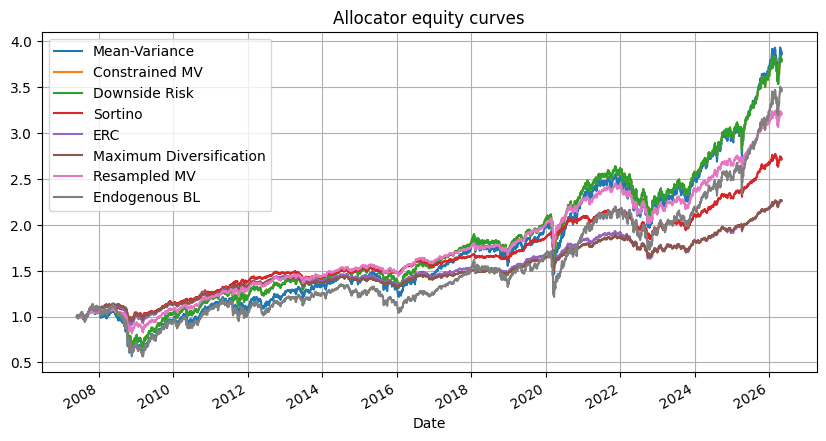

In [9]:

def evaluate_allocators(sample_returns, weights_df, risk_free_rate):
    port_rets = {}
    for name in weights_df.index:
        port_rets[name] = portfolio_series(sample_returns, weights_df.loc[name].values)
    port_rets = pd.DataFrame(port_rets)

    summary = pd.DataFrame({
        "AnnRet": annualized_return(port_rets, PERIODS_PER_YEAR),
        "AnnVol": annualized_volatility(port_rets, PERIODS_PER_YEAR),
        "DownVol": annualized_downside_volatility(port_rets, PERIODS_PER_YEAR),
        "HistVaR5": historic_var(port_rets, PERIODS_PER_YEAR, 0.05),
        "HistES5": historic_es(port_rets, PERIODS_PER_YEAR, 0.05),
        "ParVaR5": parametric_var(port_rets, PERIODS_PER_YEAR, 0.05),
        "ParES5": parametric_es(port_rets, PERIODS_PER_YEAR, 0.05),
        "MaxDD": max_drawdown(port_rets),
        "Sharpe": sharpe_ratio(port_rets, risk_free_rate, PERIODS_PER_YEAR),
        "Sortino": sortino_ratio(port_rets, risk_free_rate, PERIODS_PER_YEAR),
        "Omega": omega_ratio(port_rets, threshold=0.02, periods_per_year=PERIODS_PER_YEAR),
        "Calmar": calmar_ratio(port_rets, periods_per_year=PERIODS_PER_YEAR),
    }).sort_values("Sharpe", ascending=False)
    return port_rets, summary

portfolio_returns, summary = evaluate_allocators(returns, weights_df, rf_annual)
display(summary.round(4))

wealth = np.exp(portfolio_returns.cumsum())
wealth.plot(title="Allocator equity curves")
plt.show()


## Rolling walk-forward backtest con turnover e costi

,Gross AnnRet,Net AnnRet,Net AnnVol,Net MaxDD,Net Sharpe,Net Sortino,Avg Turnover
Sortino,0.0621,0.0608,0.0635,-0.1415,0.7469,0.9439,0.1054
Resampled MV,0.0556,0.0543,0.0563,-0.1455,0.7282,0.9148,0.1037
Maximum Diversification,0.0504,0.0500,0.0509,-0.1317,0.7201,0.9387,0.0312
Mean-Variance,0.0712,0.0689,0.0791,-0.1551,0.7021,0.8496,0.1795
Constrained MV,0.0703,0.0676,0.0854,-0.1926,0.6345,0.7851,0.2093
Downside Risk,0.0701,0.0673,0.0856,-0.1901,0.6308,0.7828,0.2124
ERC,0.0450,0.0447,0.0517,-0.1411,0.6068,0.7889,0.0251
Endogenous BL,0.0510,0.0464,0.1242,-0.3090,0.2658,0.3015,0.3662


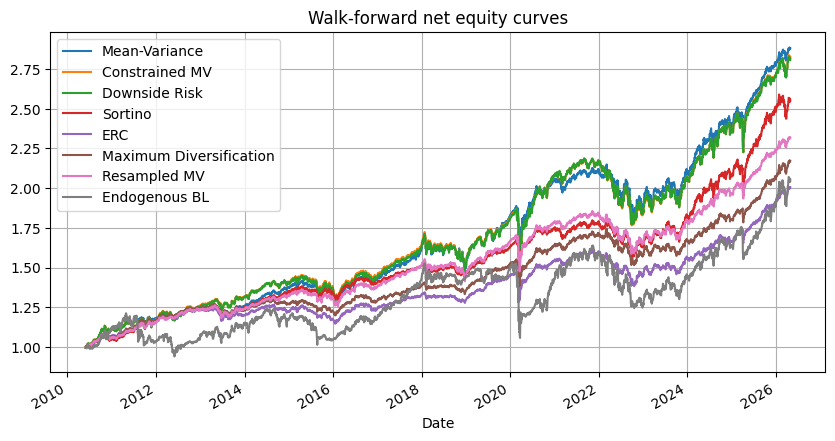

In [10]:

def make_weight_builders():
    def mv_builder(sample):
        res = solve_min_vol(sample, bounds, unconstrained_builder(sample), PERIODS_PER_YEAR)
        return pd.Series(res.x, index=sample.columns)

    def constrained_mv_builder(sample):
        res = solve_min_vol(sample, bounds, constrained_builder(sample), PERIODS_PER_YEAR)
        return pd.Series(res.x, index=sample.columns)

    def downside_builder(sample):
        res = solve_min_downside_vol(sample, bounds, constrained_builder(sample), PERIODS_PER_YEAR)
        return pd.Series(res.x, index=sample.columns)

    def sortino_builder(sample):
        rf = sample["Cash / T-Bills"].mean() * PERIODS_PER_YEAR
        res = solve_sortino(sample, bounds, base_constraints(sample, target_return=None), rf, PERIODS_PER_YEAR)
        return pd.Series(res.x, index=sample.columns)

    def erc_builder(sample):
        res = solve_erc(sample, bounds, base_constraints(sample, target_return=None))
        return pd.Series(res.x, index=sample.columns)

    def maxdiv_builder(sample):
        res = solve_max_div(sample, bounds, base_constraints(sample, target_return=None), PERIODS_PER_YEAR)
        return pd.Series(res.x, index=sample.columns)

    def resampled_builder(sample):
        w, _ = resampled_mean_variance_weights(sample, bounds, unconstrained_builder, PERIODS_PER_YEAR, n_bootstrap=100, seed=42)
        return w

    def bl_builder(sample):
        rf = sample["Cash / T-Bills"].mean() * PERIODS_PER_YEAR
        res = solve_bl_min_vol(sample, bounds, unconstrained_builder(sample), rf)
        return pd.Series(res.x, index=sample.columns)

    return {
        "Mean-Variance": mv_builder,
        "Constrained MV": constrained_mv_builder,
        "Downside Risk": downside_builder,
        "Sortino": sortino_builder,
        "ERC": erc_builder,
        "Maximum Diversification": maxdiv_builder,
        "Resampled MV": resampled_builder,
        "Endogenous BL": bl_builder,
    }

weight_builders = make_weight_builders()

wf_gross, wf_net, wf_weights, wf_turnover = rolling_walk_forward(
    returns=returns,
    weight_builders=weight_builders,
    train_window=756,        # ~3 anni
    rebalance_every=21,      # ~mensile
    cost_bps_per_unit=10.0,  # 10 bps per unità di turnover
)

wf_summary = pd.DataFrame({
    "Gross AnnRet": annualized_return(wf_gross, PERIODS_PER_YEAR),
    "Net AnnRet": annualized_return(wf_net, PERIODS_PER_YEAR),
    "Net AnnVol": annualized_volatility(wf_net, PERIODS_PER_YEAR),
    "Net MaxDD": max_drawdown(wf_net),
    "Net Sharpe": sharpe_ratio(wf_net, rf_annual, PERIODS_PER_YEAR),
    "Net Sortino": sortino_ratio(wf_net, rf_annual, PERIODS_PER_YEAR),
    "Avg Turnover": wf_turnover.mean(),
}).sort_values("Net Sharpe", ascending=False)

display(wf_summary.round(4))

np.exp(wf_net.cumsum()).plot(title="Walk-forward net equity curves")
plt.show()


## Multivariate stationary bootstrap scenarios

,Median Terminal Wealth,Mean Terminal Wealth,P05 Terminal Wealth,P95 Terminal Wealth
Mean-Variance,1.2340,1.2740,0.8082,1.7720
Downside Risk,1.2299,1.2618,0.8543,1.6958
Constrained MV,1.2299,1.2618,0.8543,1.6958
Endogenous BL,1.2290,1.2586,0.7629,1.8479
Resampled MV,1.2180,1.2160,0.9511,1.4795
Sortino,1.1784,1.1823,0.9963,1.3742
ERC,1.1494,1.1507,0.9250,1.3536
Maximum Diversification,1.1488,1.1492,0.9594,1.3305


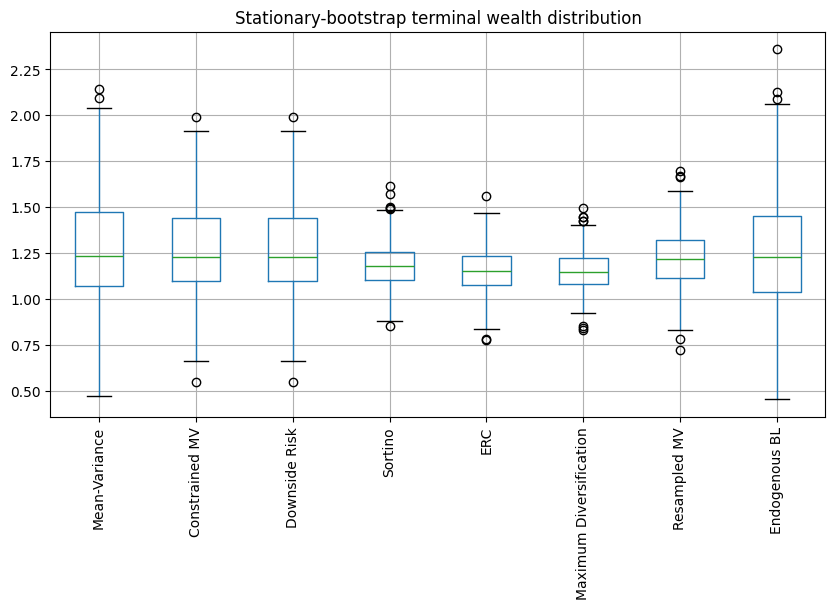

In [11]:

BOOT_HORIZON = 252 * 3
N_BOOT = 300
BOOT_EXPECTED_BLOCK = 20

boot_terminal_wealth = []
rng = np.random.default_rng(123)

for b in range(N_BOOT):
    sample = stationary_bootstrap_sample(returns, expected_length=BOOT_EXPECTED_BLOCK, horizon=BOOT_HORIZON, rng=rng)
    port_simple = {}
    for name in weights_df.index:
        rp = portfolio_series(sample, weights_df.loc[name].values)
        port_simple[name] = np.exp(rp.cumsum()).iloc[-1]
    boot_terminal_wealth.append(port_simple)

boot_terminal_wealth = pd.DataFrame(boot_terminal_wealth)

boot_summary = pd.DataFrame({
    "Median Terminal Wealth": boot_terminal_wealth.median(),
    "Mean Terminal Wealth": boot_terminal_wealth.mean(),
    "P05 Terminal Wealth": boot_terminal_wealth.quantile(0.05),
    "P95 Terminal Wealth": boot_terminal_wealth.quantile(0.95),
}).sort_values("Median Terminal Wealth", ascending=False)

display(boot_summary.round(4))

boot_terminal_wealth.boxplot(rot=90)
plt.title("Stationary-bootstrap terminal wealth distribution")
plt.show()
